In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [18]:
img_path = "/content/drive/MyDrive/AI ML/eye.png"
img = Image.open(img_path)
img_array = np.array(img)

print("Image shape:", img_array.shape)
print("Image mode:", img.mode)

Image shape: (836, 1258, 4)
Image mode: RGBA


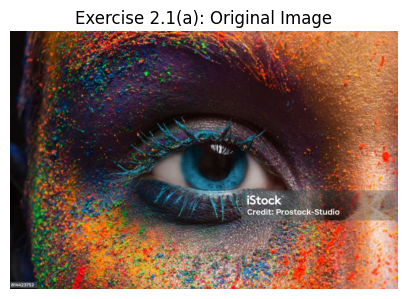

In [19]:
plt.figure(figsize=(5,5))
plt.imshow(img_array, cmap='gray')
plt.title("Exercise 2.1(a): Original Image")
plt.axis("off")
plt.show()

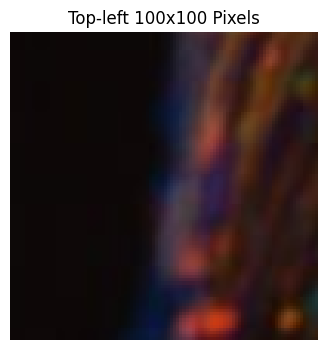

In [20]:
top_left = img_array[:100, :100]

plt.figure(figsize=(4,4))
plt.imshow(top_left, cmap='gray')
plt.title("Top-left 100x100 Pixels")
plt.axis("off")
plt.show()

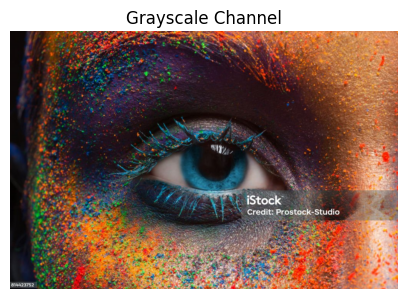

In [21]:
plt.figure(figsize=(5,5))
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Channel")
plt.axis("off")
plt.show()

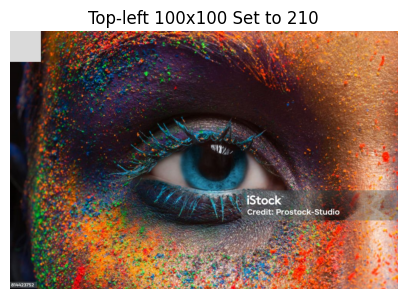

In [22]:
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.figure(figsize=(5,5))
plt.imshow(modified_img, cmap='gray')
plt.title("Top-left 100x100 Set to 210")
plt.axis("off")
plt.show()

In [23]:
from PIL import Image
import numpy as np

img = Image.open(img_path).convert('L')   # convert to grayscale
img_array = np.array(img)

h, w = img_array.shape
center_h, center_w = h // 2, w // 2
half = 75

middle_section = img_array[center_h-half:center_h+half, center_w-half:center_w+half]

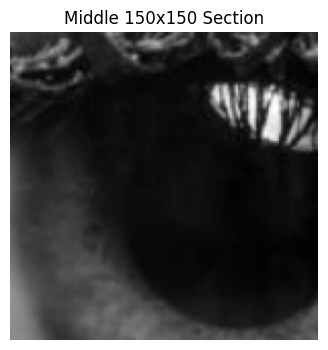

In [24]:
h, w = img_array.shape
center_h, center_w = h // 2, w // 2
half = 75

middle_section = img_array[center_h-half:center_h+half, center_w-half:center_w+half]

plt.figure(figsize=(4,4))
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

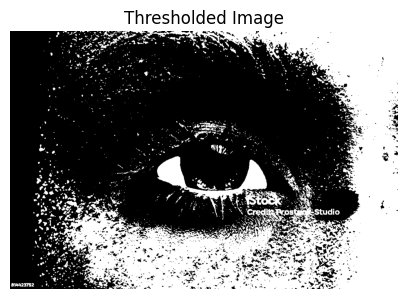

In [25]:
binary_img = np.where(img_array < 100, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(binary_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

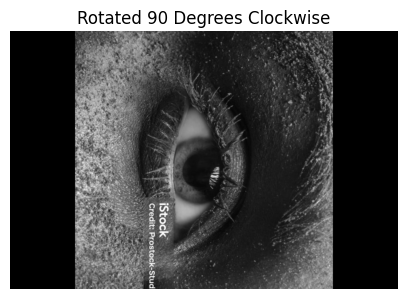

In [26]:
rotated_img = img.rotate(-90)

plt.figure(figsize=(5,5))
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

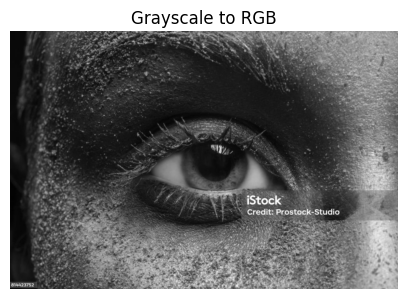

In [27]:
rgb_img = np.stack([img_array, img_array, img_array], axis=-1)

plt.figure(figsize=(5,5))
plt.imshow(rgb_img)
plt.title("Grayscale to RGB")
plt.axis("off")
plt.show()

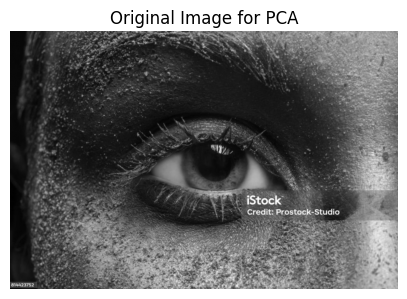

Matrix shape: (836, 1258)


In [28]:
X = img_array.astype(np.float64)

plt.figure(figsize=(5,5))
plt.imshow(X, cmap='gray')
plt.title("Original Image for PCA")
plt.axis("off")
plt.show()

print("Matrix shape:", X.shape)

In [29]:
mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector

print("Centered data shape:", X_centered.shape)

Centered data shape: (836, 1258)


In [30]:
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (1258, 1258)


In [31]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (1258,)
Eigenvectors shape: (1258, 1258)


In [32]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

print("Top 10 Eigenvalues:")
print(eigenvalues_sorted[:10])

Top 10 Eigenvalues:
[1171356.24040402  182653.45019796  142731.65325663  104441.31289931
   78128.64152521   41514.80482013   20266.15330492   19534.11368623
   17501.48708474   14389.44521413]


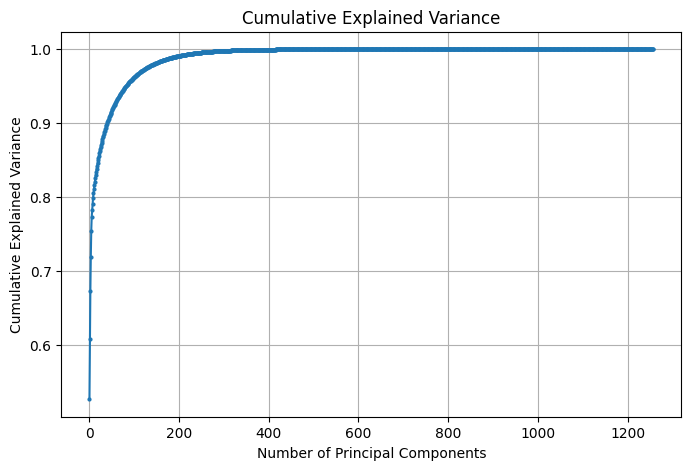

In [33]:
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(cumulative_explained_variance, marker='o', markersize=2)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [34]:
k_values = [10, 20, 50, 100]
print("Chosen principal components:", k_values)

Chosen principal components: [10, 20, 50, 100]


In [35]:
reconstructed_images = []

for k in k_values:
    W = eigenvectors_sorted[:, :k]
    X_reduced = np.dot(X_centered, W)
    X_approx = np.dot(X_reduced, W.T)
    X_reconstructed = X_approx + mean_vector
    X_reconstructed = np.clip(X_reconstructed, 0, 255)
    reconstructed_images.append(X_reconstructed)

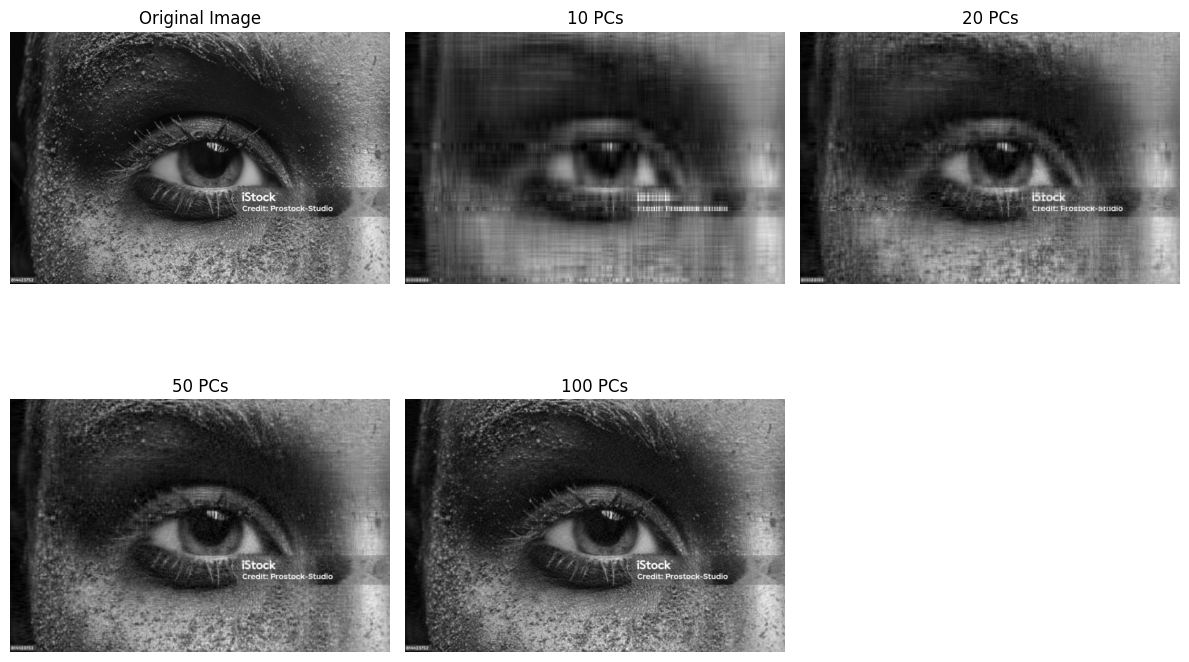

In [36]:
plt.figure(figsize=(12,8))

plt.subplot(2, 3, 1)
plt.imshow(X, cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f"{k} PCs")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
for i, k in enumerate(k_values):
    mse = np.mean((X - reconstructed_images[i]) ** 2)
    retained_variance = cumulative_explained_variance[k - 1] * 100
    print(f"k = {k}")
    print(f"Retained Variance = {retained_variance:.2f}%")
    print(f"Mean Squared Error = {mse:.2f}")
    print()

k = 10
Retained Variance = 80.50%
Mean Squared Error = 344.63

k = 20
Retained Variance = 84.95%
Mean Squared Error = 266.02

k = 50
Retained Variance = 91.57%
Mean Squared Error = 148.99

k = 100
Retained Variance = 96.19%
Mean Squared Error = 67.38

